# Mercedes-Benz Greener Manufacturing 

Description

Reduce the time a Mercedes-Benz spends on the test bench.

Problem Statement Scenario:
Since the first automobile, the Benz Patent Motor Car in 1886, Mercedes-Benz has stood for important automotive innovations. These include the passenger safety cell with a crumple zone, the airbag, and intelligent assistance systems. Mercedes-Benz applies for nearly 2000 patents per year, making the brand the European leader among premium carmakers. Mercedes-Benz is the leader in the premium car industry. With a huge selection of features and options, customers can choose the customized Mercedes-Benz of their dreams.

To ensure the safety and reliability of every unique car configuration before they hit the road, the company’s engineers have developed a robust testing system. As one of the world’s biggest manufacturers of premium cars, safety and efficiency are paramount on Mercedes-Benz’s production lines. However, optimizing the speed of their testing system for many possible feature combinations is complex and time-consuming without a powerful algorithmic approach.

You are required to reduce the time that cars spend on the test bench. Others will work with a dataset representing different permutations of features in a Mercedes-Benz car to predict the time it takes to pass testing. Optimal algorithms will contribute to faster testing, resulting in lower carbon dioxide emissions without reducing Mercedes-Benz’s standards.

Following actions should be performed:

    If for any column(s), the variance is equal to zero, then you need to remove those variable(s).
    Check for null and unique values for test and train sets.
    Apply label encoder.
    Perform dimensionality reduction.
    Predict your test_df values using XGBoost.


In [103]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [104]:
# read train and test dataset
df_train = pd.read_csv('train.csv')  
df_test = pd.read_csv('test.csv')    

In [105]:
#before moving further , lets see if columns in train and test datasets are equal or not , to run our model correctly

print("train model shape is ", df_train.shape)

print("test model shape is ", df_test.shape)




train model shape is  (4209, 378)
test model shape is  (4209, 377)


In [106]:
#identify missing column from test

set(df_train) - set(df_test)

{'y'}

In [107]:
#add missing column 'y' in test dataset

df_test['y'] = df_train['y']

In [108]:
#recheck shapes of both dataset lets see if columns in train and test datasets are equal or not , to run our model correctly

print("train model shape is ", df_train.shape)

print("test model shape is ", df_test.shape)


train model shape is  (4209, 378)
test model shape is  (4209, 378)


## If for any column(s), the variance is equal to zero, then you need to remove those variable(s).

In [109]:
#If for any column(s), the variance is equal to zero, then you need to remove those variable(s).

for colNo in df_train.columns:
    
    #check for numeric datatype and then verify variance is 0
    if pd.api.types.is_numeric_dtype(df_train[colNo]):
        if df_train[colNo].var()== 0:
            print('dropping column ' , df_train[colNo].name)
            df_train.drop(colNo, axis=1, inplace= True)


dropping column  X11
dropping column  X93
dropping column  X107
dropping column  X233
dropping column  X235
dropping column  X268
dropping column  X289
dropping column  X290
dropping column  X293
dropping column  X297
dropping column  X330
dropping column  X347


In [110]:
#If for any column(s), the variance is equal to zero, then you need to remove those variable(s).

for colNo in df_test.columns:
    
    #check for numeric datatype and then verify variance is 0
    if pd.api.types.is_numeric_dtype(df_test[colNo]):
        if df_test[colNo].var()== 0:
            print('dropping column ' , df_test[colNo].name)
            df_test.drop(colNo, axis=1, inplace= True)

dropping column  X257
dropping column  X258
dropping column  X295
dropping column  X296
dropping column  X369


In [111]:
#recheck shapes of both dataset lets see if columns in train and test datasets are equal or not , to run our model correctly

print("train model shape is ", df_train.shape)

print("test model shape is ", df_test.shape)

train model shape is  (4209, 366)
test model shape is  (4209, 373)


# Check for null and unique values for test and train sets.

In [112]:
#Check for null and unique values for test and train sets.

print('Null values in train dataset ', df_train.isnull().sum())


print('Unique values train dataset ', df_train.nunique())

print('Null values in test dataset', df_test.isnull().sum())

print('Unique values train dataset ', df_train.nunique())

Null values in train dataset  ID      0
y       0
X0      0
X1      0
X2      0
       ..
X380    0
X382    0
X383    0
X384    0
X385    0
Length: 366, dtype: int64
Unique values train dataset  ID      4209
y       2545
X0        47
X1        27
X2        44
        ... 
X380       2
X382       2
X383       2
X384       2
X385       2
Length: 366, dtype: int64
Null values in test dataset ID      0
X0      0
X1      0
X2      0
X3      0
       ..
X382    0
X383    0
X384    0
X385    0
y       0
Length: 373, dtype: int64
Unique values train dataset  ID      4209
y       2545
X0        47
X1        27
X2        44
        ... 
X380       2
X382       2
X383       2
X384       2
X385       2
Length: 366, dtype: int64


# LabelEncoder  

is a part of Scikit-Learn’s preprocessing module. It converts categorical labels (text) into numeric form.

Many ML algorithms can’t handle non-numeric data directly. LabelEncoder helps transform categories into integers so models can process them.

In [113]:
#apply same  label encoder algorithm to avoid errors , hence combined data 
for col in df_train.columns:
    if df_train[col].dtype == 'object':
        # Combine train and test data to fit the encoder
        combined_data = pd.concat([df_train[col], df_test[col]], axis=0)
        
        label_enc = LabelEncoder()
        label_enc.fit(combined_data)  # Fit on combined data
        
        df_train[col] = label_enc.transform(df_train[col])
        df_test[col] = label_enc.transform(df_test[col])
        

In [114]:
#before performing dimensional reduction, after removing variance columns make sure test and train set should have same number of columns
#hence check shapes of train and test dataset

In [115]:
print("train dataset shape ", df_train.shape)

print("test dataset shape ", df_test.shape)

train dataset shape  (4209, 366)
test dataset shape  (4209, 373)


In [116]:
#there is difference in train and test columns hence get only matching columns from train and test dataset

# Get common columns between train and test sets
common_cols = df_train.columns.intersection(df_test.columns)

# Keep only common columns
df_train = df_train[common_cols]
df_test = df_test[common_cols]


In [117]:
print("train dataset shape ", df_train.shape)

print("test dataset shape ", df_test.shape)

train dataset shape  (4209, 361)
test dataset shape  (4209, 361)


# Perform dimensionality reduction.

In [118]:
df_train

,ID,y,X0,X1,X2,X3,X4,X5,X6,X8,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,0,130.81,37,23,20,0,3,27,9,14,...,0,0,1,0,0,0,0,0,0,0
1,6,88.53,37,21,22,4,3,31,11,14,...,1,0,0,0,0,0,0,0,0,0
2,7,76.26,24,24,38,2,3,30,9,23,...,0,0,0,0,0,0,1,0,0,0
3,9,80.62,24,21,38,5,3,30,11,4,...,0,0,0,0,0,0,0,0,0,0
4,13,78.02,24,23,38,5,3,14,3,13,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4204,8405,107.39,10,20,19,2,3,1,3,16,...,1,0,0,0,0,0,0,0,0,0
4205,8406,108.77,36,16,44,3,3,1,7,7,...,0,1,0,0,0,0,0,0,0,0
4206,8412,109.22,10,23,42,0,3,1,6,4,...,0,0,1,0,0,0,0,0,0,0
4207,8415,87.48,11,19,29,5,3,1,11,20,...,0,0,0,0,0,0,0,0,0,0


In [119]:
# Split features and target
X = df_train.drop(['ID', 'y'], axis=1)
y = df_train['y']

test_X = df_test.drop(['ID','y'], axis=1)

test_X = df_test

In [120]:
# 5. Dimensionality Reduction using PCA
pca = PCA(n_components=0.95)  # Preserve 95% variance
X = pca.fit_transform(X)
test_X = pca.transform(test_X)

print("Shape after PCA:")
print("Train data shape:", X.shape)
print("Test data shape:", test_X.shape)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- ID
- y


# Predict your test_df values using XGBoost.

In [121]:
# 6. Train and Predict using XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb.fit(X, y)

# Predictions
predictions = xgb.predict(test_X)

# 7. Evaluate the model (using a train-test split for demonstration)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
xgb.fit(X_train, y_train)
val_predictions = xgb.predict(X_val)


mse = mean_squared_error(y_val, val_predictions)

rmse = np.sqrt(mean_squared_error(y_val, val_predictions))



print("mean_squared_error is : " , mse ,  " and Validation RMSE:", rmse)

#Prepare submission
# Prepare submission
csv_y_value = pd.DataFrame({'ID': df_test['ID'], 'y': predictions})

csv_y = pd.DataFrame({'y value': y_val, 'y': val_predictions})


csv_y_value.to_csv('Mercedes-Benz Greener Manufacturing_project_output.csv', index=False)
csv_y.to_csv('Mercedes-Benz Greener Manufacturing_project_y.csv', index=False)

print("Mercedes-Benz Greener Manufacturing project file output successfully!")

ValueError: Feature shape mismatch, expected: 6, got 361

In [76]:
y_mean = y_val.mean()
print("Mean of Target:", y_mean)

Mean of Target: 100.60343230403804


In [77]:
y_mean = val_predictions.mean()
print("Mean of Target:", y_mean)

Mean of Target: 100.916794


In [79]:
from sklearn.metrics import r2_score
r2 = r2_score(y_val, val_predictions)
print("R² Score:", r2)

R² Score: 0.37014558087247296


#
Next Steps for Feature Reduction

    Remove Low-Variance Features: Eliminate columns with zero or near-zero variance.
    Correlation Analysis: Identify and remove highly correlated features.
    Feature Importance: Use XGBoost to rank features.

In [49]:
#Correlation Analysis: Identify and remove highly correlated features.

df_test_copy = df_test.copy()

df_train_copy = df_train.copy()

In [55]:
df_test_copy= df_test.drop(['ID'] , axis=1)
df_train_copy =df_train.drop(['ID'] , axis=1)



In [75]:
# Calculate correlation matrix
corr_matrix = df_test_copy.corr().abs()



In [76]:
corr_matrix_train> threshold

,y,X0,X1,X2,X3,X4,X5,X6,X8,X10,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
y,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
X0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
X1,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
X2,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
X3,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
X380,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
X382,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
X383,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
X384,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [65]:
# Set threshold for high correlation
threshold = 0.9


high_corr = np.where(corr_matrix > threshold)

high_corr = [(corr_matrix.index[x], corr_matrix.columns[y]) 
                   for x, y in zip(*high_corr) if x != y and x < y]





Removed 99 highly correlated features:
{'X328', 'X251', 'X360', 'X122', 'X244', 'X147', 'X379', 'X199', 'X262', 'X140', 'X317', 'X162', 'X136', 'X66', 'X111', 'X35', 'X213', 'X194', 'X247', 'X179', 'X348', 'X363', 'X242', 'X113', 'X326', 'X358', 'X239', 'X339', 'X367', 'X119', 'X382', 'X277', 'X246', 'X279', 'X272', 'X311', 'X264', 'X254', 'X238', 'X362', 'X265', 'X352', 'X158', 'X54', 'X187', 'X102', 'X371', 'X198', 'X205', 'X146', 'X346', 'X137', 'X299', 'X293', 'X276', 'X314', 'X226', 'X61', 'X302', 'X308', 'X364', 'X215', 'X368', 'X134', 'X250', 'X229', 'X365', 'X232', 'X249', 'X101', 'X337', 'X76', 'X243', 'X39', 'X378', 'X94', 'X370', 'X130', 'X260', 'X129', 'X214', 'X120', 'X324', 'X241', 'X385', 'X217', 'X90', 'X330', 'X263', 'X222', 'X320', 'X172', 'X227', 'X37', 'X157', 'X186', 'X253', 'X216', 'X84'}


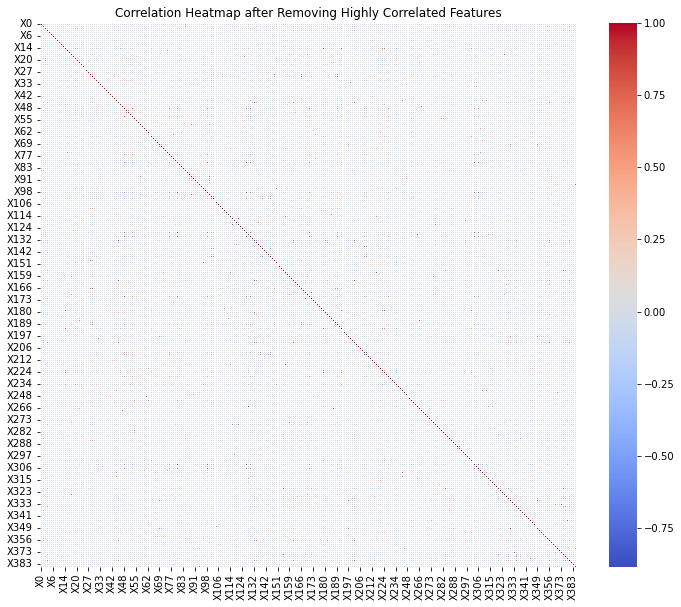

In [73]:
# Remove one feature from each pair of highly correlated features
cols_to_drop = set()
for feature1, feature2 in high_corr:
    cols_to_drop.add(feature2)  # Drop the second feature arbitrarily

df_reduced = df_test_copy.drop(columns=cols_to_drop)

print(f"\nRemoved {len(cols_to_drop)} highly correlated features:")
print(cols_to_drop)

from matplotlib.pylab import plt

import seaborn as sns

# Plot correlation heatmap for reduced dataset
plt.figure(figsize=(12, 10))
sns.heatmap(df_reduced.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap after Removing Highly Correlated Features')
plt.show()

In [79]:
high_corr_train

[('X14', 'X251'),
 ('X17', 'X382'),
 ('X19', 'X215'),
 ('X29', 'X54'),
 ('X29', 'X76'),
 ('X29', 'X136'),
 ('X29', 'X162'),
 ('X29', 'X232'),
 ('X29', 'X263'),
 ('X29', 'X272'),
 ('X29', 'X276'),
 ('X29', 'X279'),
 ('X29', 'X328'),
 ('X31', 'X35'),
 ('X31', 'X37'),
 ('X33', 'X39'),
 ('X35', 'X37'),
 ('X44', 'X302'),
 ('X48', 'X66'),
 ('X48', 'X111'),
 ('X48', 'X113'),
 ('X48', 'X134'),
 ('X48', 'X147'),
 ('X48', 'X198'),
 ('X48', 'X222'),
 ('X49', 'X129'),
 ('X52', 'X61'),
 ('X52', 'X120'),
 ('X53', 'X102'),
 ('X53', 'X214'),
 ('X53', 'X239'),
 ('X53', 'X370'),
 ('X54', 'X76'),
 ('X54', 'X136'),
 ('X54', 'X162'),
 ('X54', 'X232'),
 ('X54', 'X263'),
 ('X54', 'X272'),
 ('X54', 'X276'),
 ('X54', 'X279'),
 ('X54', 'X328'),
 ('X58', 'X137'),
 ('X58', 'X324'),
 ('X60', 'X248'),
 ('X60', 'X253'),
 ('X60', 'X385'),
 ('X61', 'X120'),
 ('X62', 'X172'),
 ('X62', 'X216'),
 ('X63', 'X379'),
 ('X66', 'X111'),
 ('X66', 'X113'),
 ('X66', 'X134'),
 ('X66', 'X147'),
 ('X66', 'X222'),
 ('X67', 'X213'),
 

In [80]:
corr_matrix_train = df_train_copy.corr().abs()

In [81]:
# Set threshold for high correlation
threshold = 0.9


high_corr_train = np.where(corr_matrix_train > threshold)

high_corr_train = [(corr_matrix_train.index[x], corr_matrix_train.columns[y]) 
                   for x, y in zip(*high_corr_train) if x != y and x < y]


In [82]:
# Remove one feature from each pair of highly correlated features
cols_to_drop_train = set()
for feature1, feature2 in high_corr_train:
    cols_to_drop_train.add(feature2)  # Drop the second feature arbitrarily

df_reduced_train = df_train_copy.drop(columns=cols_to_drop)

print(f"\nRemoved {len(cols_to_drop)} highly correlated features:")
print(cols_to_drop)

from matplotlib.pylab import plt

import seaborn as sns

# Plot correlation heatmap for reduced dataset
plt.figure(figsize=(12, 10))
sns.heatmap(df_reduced_train.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap after Removing Highly Correlated Features')
plt.show()

KeyError: "['X293' 'X330'] not found in axis"

In [68]:
print("Highly Correlated Pairs (above 0.9):")
for pair in high_corr:
    print(pair)

Highly Correlated Pairs (above 0.9):
('X14', 'X251')
('X15', 'X260')
('X17', 'X382')
('X19', 'X215')
('X29', 'X54')
('X29', 'X76')
('X29', 'X136')
('X29', 'X162')
('X29', 'X232')
('X29', 'X263')
('X29', 'X272')
('X29', 'X276')
('X29', 'X279')
('X29', 'X328')
('X31', 'X35')
('X31', 'X37')
('X33', 'X39')
('X35', 'X37')
('X44', 'X302')
('X44', 'X317')
('X48', 'X66')
('X48', 'X111')
('X48', 'X113')
('X48', 'X134')
('X48', 'X147')
('X48', 'X198')
('X48', 'X222')
('X49', 'X129')
('X52', 'X61')
('X52', 'X120')
('X53', 'X102')
('X53', 'X214')
('X53', 'X239')
('X53', 'X308')
('X53', 'X370')
('X54', 'X76')
('X54', 'X136')
('X54', 'X162')
('X54', 'X232')
('X54', 'X263')
('X54', 'X272')
('X54', 'X276')
('X54', 'X279')
('X54', 'X328')
('X58', 'X137')
('X58', 'X324')
('X60', 'X253')
('X60', 'X385')
('X61', 'X120')
('X62', 'X172')
('X62', 'X216')
('X63', 'X379')
('X66', 'X111')
('X66', 'X113')
('X66', 'X134')
('X66', 'X147')
('X66', 'X198')
('X66', 'X222')
('X67', 'X213')
('X71', 'X84')
('X71', 'X241